# 05 — Interpretability (SHAP)

[04_advanced_modeling.ipynb](04_advanced_modeling.ipynb) found that the
original full-feature model's near-perfect scores were driven by leakage
through post-transaction fields, and established the **pre-transaction
model** as this project's primary, deployable result. This notebook explains
*that* model with SHAP -- not the leaky one -- because an explanation of a
model we'd never actually deploy isn't useful to anyone.

We do keep one short section using SHAP on the old full-feature model, but
only as a visual confirmation of the leakage finding, clearly labeled as
such.

## Why explainability matters here, not just performance

This isn't just good practice -- in financial services it's often a
**regulatory and model-risk-management requirement**, not a nice-to-have:

- **Model risk management (e.g. SR 11-7 style expectations)** requires banks
  and payment processors to be able to explain and justify automated
  decisions, not just report an accuracy number.
- **Customer-facing consequences** -- a false positive here means a real
  customer's transaction gets held or declined. Being able to tell a support
  agent (or the customer) *why* a transaction was flagged is part of
  handling that fairly.
- **Auditability** -- when a fraud case goes to investigation or litigation,
  "the model said so" is not an acceptable answer.
- **Debugging blind spots** -- as this project just demonstrated,
  explainability is also how you catch leakage in the first place.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/processed/engineered_transactions.csv")
metadata = joblib.load("models/model_metadata.joblib")

pretxn_model = joblib.load("models/best_pretransaction_model.joblib")
pretxn_feature_cols = metadata["pre_txn_feature_cols"]
print("Primary (deployable) model being explained:", metadata["best_pretxn_model_name"])

cutoff_step = np.quantile(df["step"], 0.8)
test_mask = df["step"] > cutoff_step

X_test_pre = df.loc[test_mask, pretxn_feature_cols]
y_test = df.loc[test_mask, "isFraud"]
scores_test = pretxn_model.predict_proba(X_test_pre)[:, 1]
preds_test = (scores_test >= 0.5).astype(int)


Primary (deployable) model being explained: XGBoost + undersample


A quick compatibility note: the installed `shap` release doesn't parse the
newer `xgboost` model-serialization format used by our XGBoost models
(a known version-skew issue between the two libraries, unrelated to
anything in this project's data or logic). Rather than downgrading either
library, we compute SHAP values two different ways depending on the model
type -- XGBoost's own native contribution output for XGBoost models, and
`shap.TreeExplainer` for scikit-learn models -- and wrap both behind one
consistent interface so the rest of this notebook doesn't need to care which
model won.


In [2]:
def make_shap_explainer(model, feature_cols):
    """Returns a function (X -> (shap_values, base_values)) for the fraud class,
    using XGBoost's own contribution output for XGBoost models (sidesteps a
    shap/xgboost version-compatibility bug) and shap.TreeExplainer otherwise."""
    if isinstance(model, xgb.XGBClassifier):
        booster = model.get_booster()

        def compute(X):
            dmat = xgb.DMatrix(X, feature_names=feature_cols)
            contribs = booster.predict(dmat, pred_contribs=True)
            return contribs[:, :-1], contribs[:, -1]  # shap values, per-row base value

        return compute

    explainer = shap.TreeExplainer(model)

    def compute(X):
        sv = explainer.shap_values(X)
        if isinstance(sv, list):
            sv = sv[1]
        elif sv.ndim == 3:
            sv = sv[:, :, 1]
        base = explainer.expected_value
        if isinstance(base, (list, np.ndarray)):
            base = base[1] if len(np.atleast_1d(base)) > 1 else np.atleast_1d(base)[0]
        return sv, np.full(len(X), base)

    return compute


## 1. Global feature importance -- the primary (pre-transaction) model

For computational efficiency, we compute SHAP values on a random sample of
the test set rather than all ~550K rows -- at a few thousand transactions,
the global pattern is already stable.


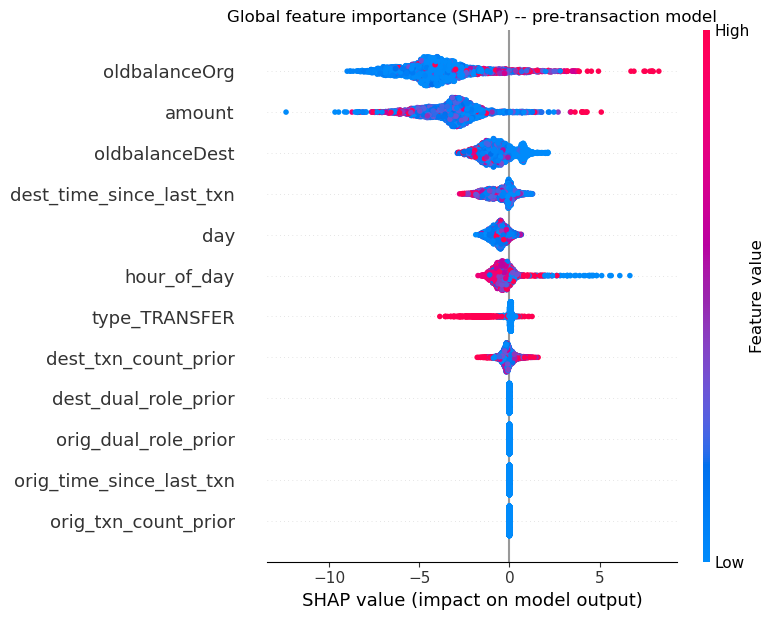

In [3]:
sample = X_test_pre.sample(3000, random_state=42)

pretxn_shap = make_shap_explainer(pretxn_model, pretxn_feature_cols)
shap_values_fraud, base_values_fraud = pretxn_shap(sample)

shap.summary_plot(shap_values_fraud, sample, show=False)
plt.title("Global feature importance (SHAP) -- pre-transaction model")
plt.tight_layout()
plt.show()


With the post-transaction balance fields removed, the model now leans on a
different mix: raw transaction `amount`, the account's balances *before*
the transaction (`oldbalanceOrg`, `oldbalanceDest`), transaction type, time
features, and the account-behavior features from 02 (frequency, recency,
dual-role). None of these require knowing how the transaction turns out --
which is the entire point.

## 2. For contrast: SHAP on the old full-feature (upper-bound) model

This is not the model we're explaining going forward -- it's a quick visual
cross-check of the leakage finding from 04, using the same technique.


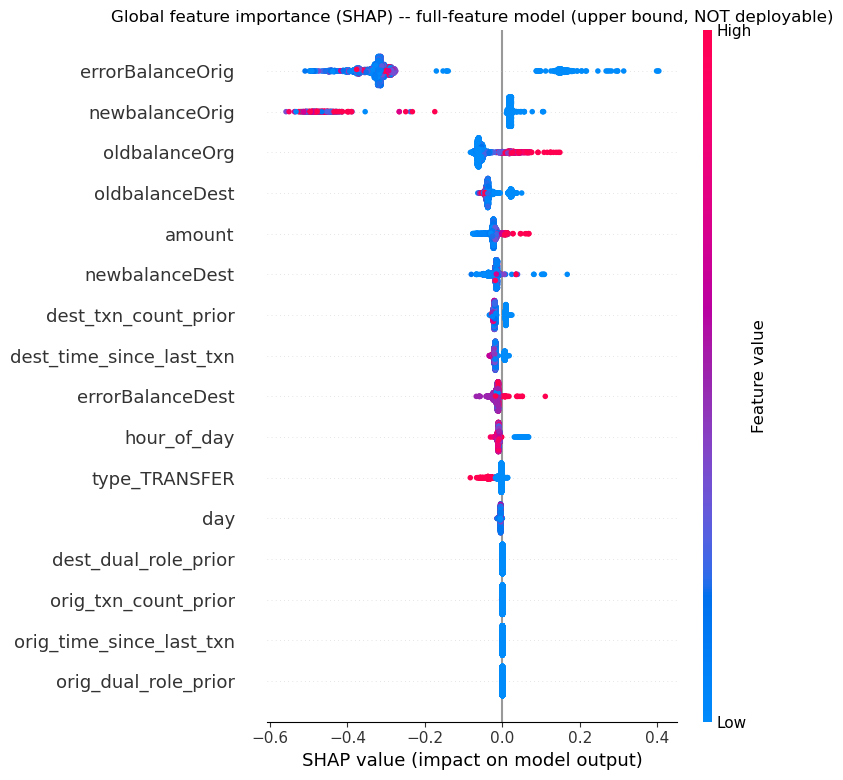

In [4]:
full_model = joblib.load("models/best_full_feature_model.joblib")
full_feature_cols = metadata["full_feature_cols"]
X_test_full = df.loc[test_mask, full_feature_cols]

full_sample = X_test_full.loc[sample.index]
full_shap = make_shap_explainer(full_model, full_feature_cols)
full_shap_values, _ = full_shap(full_sample)

shap.summary_plot(full_shap_values, full_sample, show=False)
plt.title("Global feature importance (SHAP) -- full-feature model (upper bound, NOT deployable)")
plt.tight_layout()
plt.show()


This confirms what 04 found via `feature_importances_`: `errorBalanceOrig`
and the raw post-transaction balance fields dominate this version of the
model. SHAP agrees with the plain feature-importance ranking -- two
independent methods pointing at the same leak is a good sign the diagnosis
in 04 was correct, not a fluke of one particular technique.

## 3. Individual case explanations -- primary model

Global importance tells us what matters on average. For individual
transactions, we want a specific rationale. We pull three illustrative
cases from the pre-transaction model's test-set predictions:

- **A true positive** -- real fraud, and the model was confident about it
- **A false negative** -- real fraud the model missed
- **A false positive** -- a legitimate transaction the model flagged anyway

Unlike the old full-feature model (which had almost no errors to look at),
the pre-transaction model makes enough mistakes that these are genuinely
representative examples, not one-off curiosities.


In [5]:
results_df = X_test_pre.copy()
results_df["isFraud"] = y_test.values
results_df["predicted_score"] = scores_test
results_df["predicted_label"] = preds_test

true_positives = results_df[(results_df["isFraud"] == 1) & (results_df["predicted_label"] == 1)]
false_negatives = results_df[(results_df["isFraud"] == 1) & (results_df["predicted_label"] == 0)]
false_positives = results_df[(results_df["isFraud"] == 0) & (results_df["predicted_label"] == 1)]

tp_case = true_positives.sort_values("predicted_score", ascending=False).iloc[[0]]
fn_case = false_negatives.sort_values("predicted_score", ascending=True).iloc[[0]]
fp_case = false_positives.sort_values("predicted_score", ascending=False).iloc[[0]]

print(f"True positives available:  {len(true_positives):,}")
print(f"False negatives available: {len(false_negatives):,}")
print(f"False positives available: {len(false_positives):,}")


True positives available:  3,818
False negatives available: 440
False positives available: 2,059


--- True Positive -- correctly caught fraud (pre-transaction model) ---
Actual isFraud: 1 | Predicted probability: 1.0000


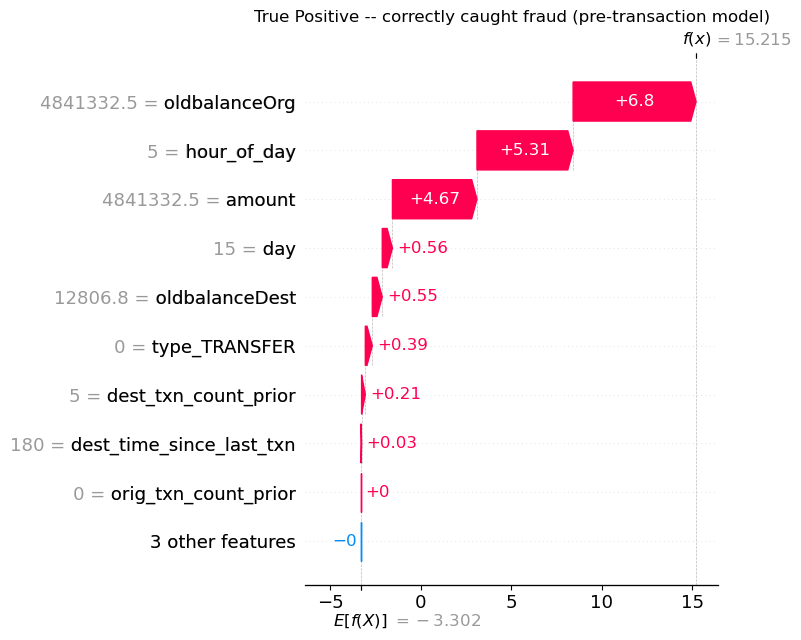

In [6]:
def explain_case(case_row, title):
    x = case_row[pretxn_feature_cols]
    sv, base = pretxn_shap(x)
    exp = shap.Explanation(
        values=sv[0], base_values=base[0],
        data=x.iloc[0].values, feature_names=pretxn_feature_cols,
    )
    print(f"--- {title} ---")
    print(f"Actual isFraud: {int(case_row['isFraud'].iloc[0])} | "
          f"Predicted probability: {case_row['predicted_score'].iloc[0]:.4f}")
    shap.plots.waterfall(exp, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

explain_case(tp_case, "True Positive -- correctly caught fraud (pre-transaction model)")


--- False Negative -- fraud the model missed (pre-transaction model) ---
Actual isFraud: 1 | Predicted probability: 0.0001


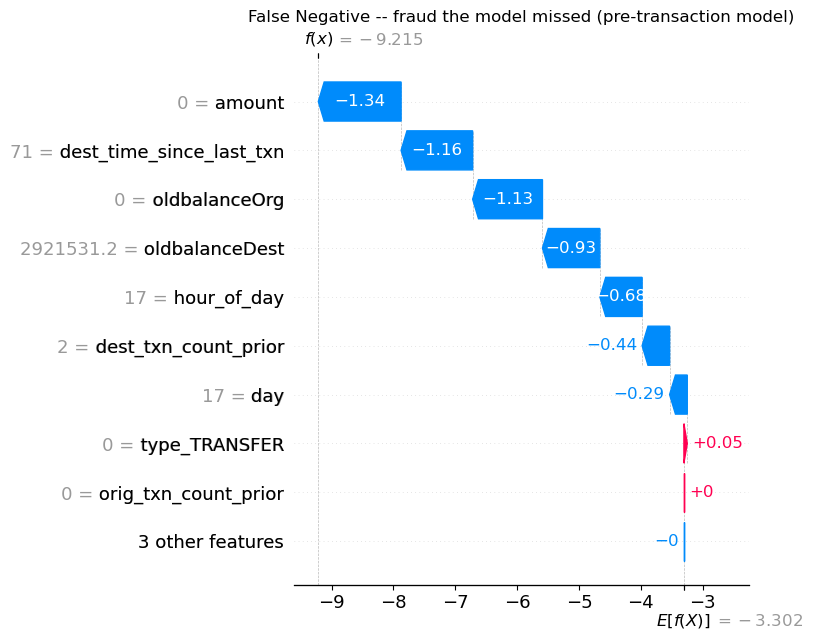

In [7]:
explain_case(fn_case, "False Negative -- fraud the model missed (pre-transaction model)")


--- False Positive -- legitimate transaction incorrectly flagged (pre-transaction model) ---
Actual isFraud: 0 | Predicted probability: 1.0000


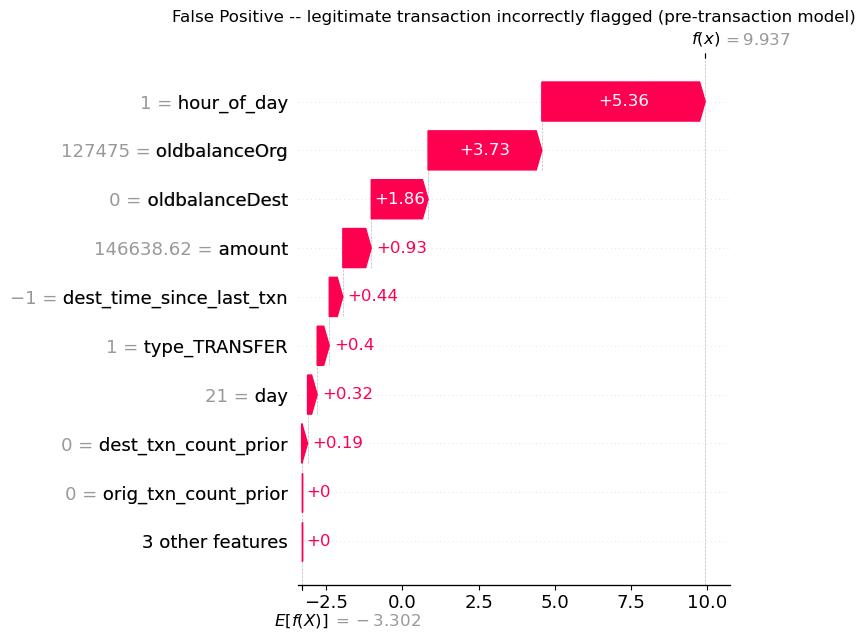

In [8]:
explain_case(fp_case, "False Positive -- legitimate transaction incorrectly flagged (pre-transaction model)")


## Summary

- The pre-transaction model's decisions are driven by a genuinely different
  (and deployable) mix of features than the leaky full-feature model --
  amount, prior balances, transaction type, timing, and account behavior,
  none of which require knowing how a transaction turns out.
- SHAP on the old full-feature model independently confirms the leakage
  finding from 04: it's dominated by `errorBalanceOrig` and other
  post-transaction fields.
- Individual case explanations on the pre-transaction model make its
  (more modest, more honest) predictions auditable -- exactly what a
  compliance or investigations team would need.

**Next:** [06_error_analysis.ipynb](06_error_analysis.ipynb) systematically
characterizes the pre-transaction model's false negatives and false
positives across the whole test set and ties the findings back to concrete
feature engineering recommendations.
